In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

%run src/donnees.py

# df_caract_recoder
# df_lieux_recoder
# df_vehicule_recoder
# df_usager_recoder
# df_final

/home/onyxia/work/Projet_pythonDS/src/donnees.py:25: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lieux_23 = pd.read_csv(url_lieux_23, sep=';', encoding='UTF-8')
/home/onyxia/work/Projet_pythonDS/src/donnees.py:26: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lieux_22 = pd.read_csv(url_lieux_22, sep=';', encoding='UTF-8')


## Visualisation des données

In [4]:
df_final.head(3)

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,manv,id_usager,catu,grav,sexe,trajet,secu1,secu2,secu3,age
0,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Déporté,203 988 581,Conducteur,Blessé hospitalisé,Homme,Domicile - École,Ceinture,Non renseigné,Non renseigné,23
1,202400000001,25,mars,2024,07:40,Crépuscule ou aube,70,70285,Hors agglomération,Hors intersection,...,Manœuvre d’évitement,203 988 582,Conducteur,Indemne,Homme,Utilisation professionnelle,Ceinture,Non renseigné,Non renseigné,29
2,202400000002,20,mars,2024,15:05,Plein jour,21,21054,En agglomération,Intersection en T,...,Tournant,203 988 579,Piéton,Blessé hospitalisé,Femme,Promenade - loisirs,Aucun équipement,Non renseigné,Non renseigné,99


In [5]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452976 entries, 0 to 452975
Data columns (total 47 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Num_Acc      452976 non-null  Int64 
 1   jour         452976 non-null  int64 
 2   mois         452976 non-null  object
 3   an           452976 non-null  int64 
 4   hrmn         452976 non-null  object
 5   lum          452969 non-null  object
 6   dep          452976 non-null  object
 7   com          452976 non-null  object
 8   agg          452976 non-null  object
 9   int          452947 non-null  object
 10  atm          452976 non-null  object
 11  col          452976 non-null  object
 12  adr          438983 non-null  object
 13  lat          452976 non-null  object
 14  long         452976 non-null  object
 15  catr         452976 non-null  object
 16  voie         385286 non-null  object
 17  v1           452976 non-null  int64 
 18  v2           39269 non-null   object
 19  ci

In [6]:
df_final["hr"] = df_final["hrmn"].str[0:2]
df_final["hr"]

0         07
1         07
2         15
3         15
4         15
          ..
452971    08
452972    08
452973    08
452974    16
452975    16
Name: hr, Length: 452976, dtype: object

`describe` nous renseigne sur la distribution des variables numériques :

In [7]:
df_final.describe()

,Num_Acc,jour,an,v1,situ,vma,age
count,452976.0,452976.000000,452976.000000,452976.000000,452976.000000,452976.000000,443048.0
mean,202307956766.712158,15.552389,2023.079293,-0.212062,1.526812,56.398487,41.721087
std,79514021.019897,8.738000,0.795142,0.421107,1.533759,27.150398,19.153206
min,202200000001.0,1.000000,2022.000000,-1.000000,-1.000000,-1.000000,2.0
25%,202200049458.0,8.000000,2022.000000,0.000000,1.000000,50.000000,26.0
50%,202300033451.0,15.000000,2023.000000,0.000000,1.000000,50.000000,38.0
75%,202400016534.0,23.000000,2024.000000,0.000000,1.000000,80.000000,55.0
max,202400054402.0,31.000000,2024.000000,3.000000,8.000000,900.000000,113.0


In [ ]:
# accidents_par_grav_atm = df_final.groupby(["grav", "atm"]).count().reset_index()
# accidents_par_grav_atm

In [9]:
plt.bar(accidents_par_grav_atm[variable], accidents_par_grav_atm["Num_Acc"])
plt.grid(which="both", axis="y")
plt.xticks(accidents_par_grav_atm[variable])
plt.xlabel(nom_variable)
plt.ylabel("Accidents")
plt.title(f"Nombre d'accidents selon leur {nom_variable.lower()}")
plt.show()

NameError: name 'variable' is not defined

In [10]:
def nb_accidents_par(variable, nom_variable):
    nb_accidents_groupe = df_final.groupby(variable).count().reset_index()
    plt.bar(nb_accidents_groupe[variable], nb_accidents_groupe["Num_Acc"])
    plt.grid(which="both", axis="y")
    plt.xticks(nb_accidents_groupe[variable])
    plt.xlabel(nom_variable)
    plt.ylabel("Accidents")
    plt.title(f"Nombre d'accidents selon leur {nom_variable.lower()}")
    plt.show()

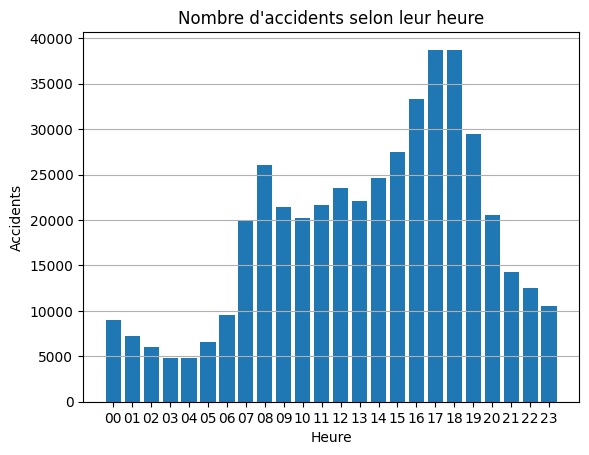

In [11]:
nb_accidents_par("hr", "Heure")

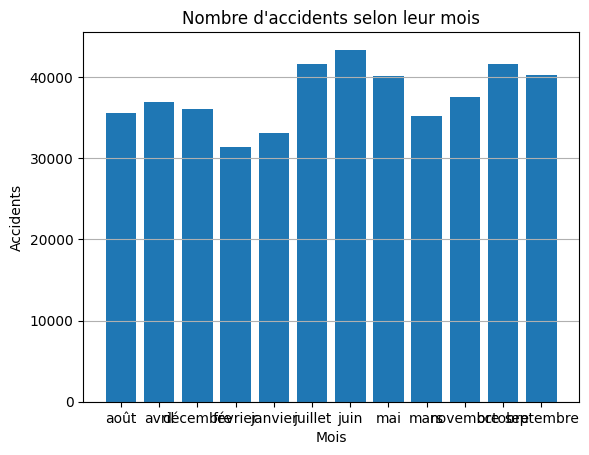

In [12]:
nb_accidents_par("mois", "Mois")

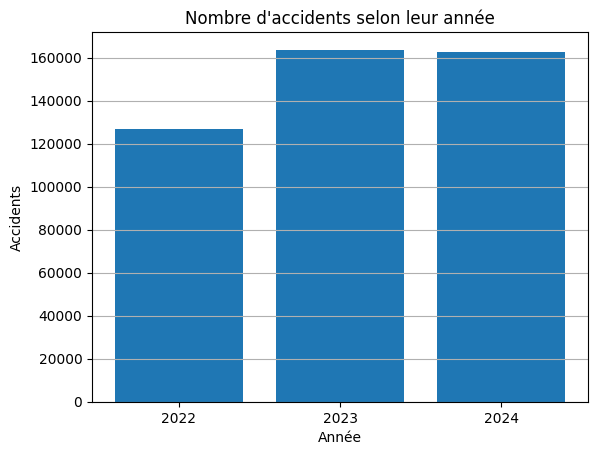

In [13]:
nb_accidents_par("an", "Année")

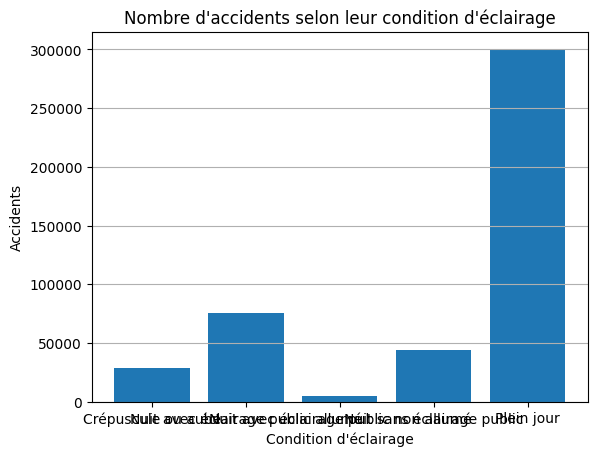

In [14]:
nb_accidents_par("lum", "Condition d'éclairage")

In [15]:
ordre_colonnes = [
    "Indemne", 
    "Blessé léger", 
    "Blessé hospitalisé", 
    "Tué"
]
ordre_lignes  = [
    "Normale", 
    "Pluie légère", 
    "Pluie forte", 
    "Neige - grêle", 
    "Brouillard - fumée", 
    "Vent fort - tempête", 
    "Temps éblouissant", 
    "Temps couvert", 
    "Autre", 
    "Non renseigné"
]

tc_atm_grav = pd.crosstab(df_final["atm"], df_final["grav"], normalize='index').reindex(columns=ordre_colonnes).reindex(index=ordre_lignes)

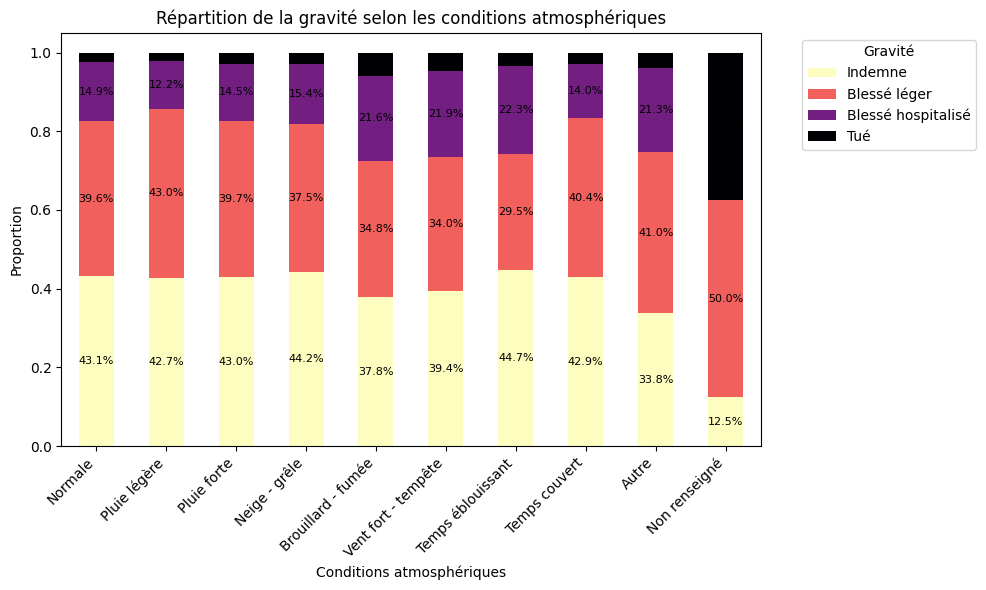

In [ ]:
n = len(tc_atm_grav.columns)
colors = [cm.magma(i / (n - 1)) for i in range(n)][::-1]

fig, ax = plt.subplots(figsize=(10, 6))

tc_atm_grav.plot(kind="bar", stacked=True, ax=ax, color=colors)

# Ajout des proportions sur chaque segment
for bar_stack in ax.containers:
    for bar in bar_stack:
        height = bar.get_height()
        if height > 0.03:  # seuil pour éviter les labels illisibles
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f"{height:.1%}",
                ha="center", va="center",
                fontsize=8, color="black"
            )

plt.xlabel("Conditions atmosphériques")
plt.ylabel("Gravité")
plt.title("Répartition de la gravité de l'accident selon les conditions atmosphériques")
plt.legend(title="Gravité", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
ordre_lignes = [
   "Normale",
   "Mouillée",
   "Flaques",
   "Inondée",
   "Enneigée",
   "Boue",
   "Verglacée",
   "Corps gras - Huile",
   "Autre",
   "Non renseigné"
]

pd.crosstab(df_final["surf"], df_final["grav"], normalize='index').reindex(columns=ordre_colonnes).reindex(index=ordre_lignes)

grav,Indemne,Blessé léger,Blessé hospitalisé,Tué
surf,,,,
Normale,0.433015,0.392850,0.149306,0.024830
Mouillée,0.422800,0.418617,0.133113,0.025470
Flaques,0.373563,0.458333,0.155172,0.012931
Inondée,0.372449,0.403061,0.132653,0.091837
Enneigée,0.444828,0.363793,0.162069,0.029310
Boue,0.247899,0.315126,0.357143,0.079832
Verglacée,0.363511,0.396683,0.196268,0.043538
Corps gras - Huile,0.261146,0.475584,0.248408,0.014862
Autre,0.290049,0.371359,0.288228,0.050364


In [ ]:
ordre_lignes = [
    "Autoroute",
    "Route nationale",
    "Route départementale",
    "Voie communale",
    "Hors réseau public",
    "Parc de stationnement ouvert à la circulation publique",
    "Route de métropole urbaine",
    "Autre"
]

pd.crosstab(df_final["catr"], df_final["grav"], normalize='index').reindex(columns=ordre_colonnes).reindex(index=ordre_lignes)

grav,Indemne,Blessé léger,Blessé hospitalisé,Tué
catr,,,,
Autoroute,0.470023,0.423265,0.087505,0.019207
Route nationale,0.416085,0.387565,0.160046,0.036304
Route départementale,0.398957,0.351464,0.210560,0.039019
Voie communale,0.450661,0.434735,0.102285,0.012318
Hors réseau public,0.364903,0.364903,0.220056,0.050139
Parc de stationnement ouvert à la circulation publique,0.473224,0.331561,0.167490,0.027725
Route de métropole urbaine,0.430477,0.406285,0.140253,0.022985
Autre,0.373813,0.365672,0.210991,0.049525
